In [12]:
!pip install tensorflow

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import joblib

In [15]:
df = pd.read_csv("ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [17]:
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(data[features])

In [18]:
def create_sequences(data, labels, window=10):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(labels[i+window])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_features, data[target].values)

In [19]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(X_train, y_train, epochs=15, batch_size=32, validation_split=0.2)

Epoch 1/15


C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9656 - loss: 0.1751 - val_accuracy: 0.9550 - val_loss: 0.1908
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9667 - loss: 0.1514 - val_accuracy: 0.9550 - val_loss: 0.1827
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9667 - loss: 0.1505 - val_accuracy: 0.9550 - val_loss: 0.1813
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9667 - loss: 0.1481 - val_accuracy: 0.9550 - val_loss: 0.1745
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9667 - loss: 0.1478 - val_accuracy: 0.9550 - val_loss: 0.1745
Epoch 6/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9667 - loss: 0.1440 - val_accuracy: 0.9550 - val_loss: 0.1784
Epoch 7/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9667 - loss: 0.1434 - val_accuracy: 0.9550 - val_loss: 0.1782
Epoch 8/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9667 - loss: 0.1438 - val_accuracy: 0.955

In [22]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"LSTM Test Accuracy: {accuracy:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9730 - loss: 0.1138
LSTM Test Accuracy: 0.9730


In [23]:
model.save("lstm_predictive_model.h5")
joblib.dump(scaler, "lstm_scaler.pkl")

print("✔ Saved: lstm_predictive_model.h5 and lstm_scaler.pkl")

✔ Saved: lstm_predictive_model.h5 and lstm_scaler.pkl


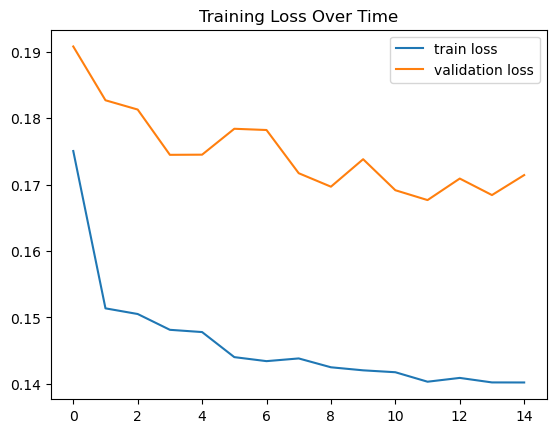

In [24]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.legend()
plt.title("Training Loss Over Time")
plt.show()

In [28]:
# LSTM Inference Helper (Load + Predict)

import numpy as np
import pandas as pd
import joblib
from tensorflow.keras.models import load_model

# 1. Load saved model and scaler
lstm_model = load_model("lstm_predictive_model.h5", compile=False)  # compile=False -> no metrics warning
lstm_scaler = joblib.load("lstm_scaler.pkl")

# 2. Helper function to predict failure for ONE time window
def predict_failure_lstm(raw_window_2d, threshold: float = 0.5):
    """
    raw_window_2d : numpy array of shape (window, 5)
        Columns order (MUST match training):
        [Air temperature [K],
         Process temperature [K],
         Rotational speed [rpm],
         Torque [Nm],
         Tool wear [min]]

    threshold : float
        Probability cutoff for class 1 (failure).

    Returns:
        label  : 0 (no failure) or 1 (failure)
        proba  : predicted probability of failure (float)
    """

    feature_cols = [
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]"
    ]

    # Convert to DataFrame so scaler sees feature names (removes warning)
    window_df = pd.DataFrame(raw_window_2d, columns=feature_cols)

    # Scale using the SAME scaler as training
    scaled = lstm_scaler.transform(window_df)

    # Add batch dimension -> (1, window, 5)
    X_seq = np.expand_dims(scaled, axis=0)

    # Predict probability of failure
    proba = float(lstm_model.predict(X_seq)[0][0])
    label = int(proba >= threshold)

    return label, proba


# 3. 🔍 Quick test with an example 10-step window
example_window = np.array([
    [300, 310, 1500, 40, 50],
    [300, 310, 1505, 40, 50],
    [301, 311, 1510, 39, 51],
    [301, 311, 1512, 39, 51],
    [302, 311, 1515, 38, 52],
    [302, 312, 1515, 38, 52],
    [302, 312, 1520, 38, 53],
    [303, 312, 1525, 37, 54],
    [303, 313, 1530, 37, 54],
    [303, 313, 1535, 37, 55],
])

label, proba = predict_failure_lstm(example_window)

print(f"Predicted label: {label}")
print(f"Failure probability: {proba:.6f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 588ms/step
Predicted label: 0
Failure probability: 0.015447
